# Exercise 19.1e solution

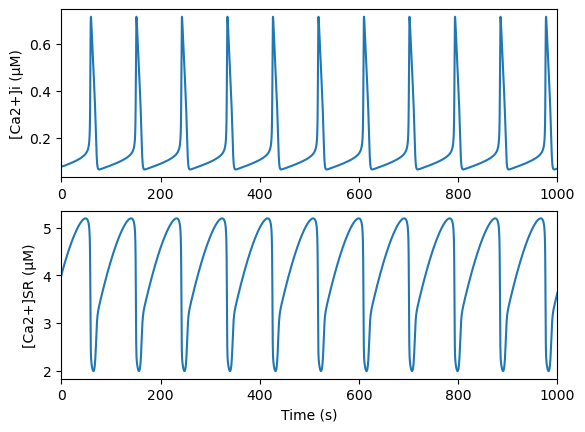

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def rhs_friel(t, y, Cao, k_entry, k_extrusion, k_uptake, kappa0, kappa1, Kd, n, gamma):
    Cai, CaSR = y
    J_entry = k_entry * (Cao - Cai)
    J_extrusion = k_extrusion * Cai
    J_uptake = k_uptake * Cai
    k_rel = kappa0 + kappa1 * Cai**n / (Kd**n + Cai**n)
    J_rel = k_rel * (CaSR - Cai)
    dCai_dt = J_entry + J_rel - J_extrusion - J_uptake
    dCaSR_dt = (J_uptake - J_rel) / gamma
    return [dCai_dt, dCaSR_dt]


params = (1000, 2e-5, 0.132, 0.9, 0.013, 0.58, 0.5, 3.0, 0.24)
sol = solve_ivp(rhs_friel, (0, 1000), [0.08, 4.0], args=params, max_step=0.1)

plt.subplot(2, 1, 1)
plt.plot(sol.t, sol.y[0])
plt.ylabel("[Ca2+]i (µM)")
plt.xlim(0, 1000)
plt.subplot(2, 1, 2)
plt.plot(sol.t, sol.y[1])
plt.ylabel("[Ca2+]SR (µM)")
plt.xlabel("Time (s)")
plt.xlim(0, 1000)
plt.show()